# Chapter 8: Triangle Counting

Triangle counting using A² ⊙ A (element-wise multiply of A-squared with A).

In [1]:
import graphblas as gb
from graphblas import Matrix, Vector, semiring, binary
from graphblas import io as gbio
import networkx as nx
import matplotlib.pyplot as plt
from graph_utils import draw_graph, draw_vector

## Zachary's Karate Club Graph

The karate club graph is a classic social network of 34 members with 78 edges representing friendships.

In [2]:
# Load karate club graph from Matrix Market format
A = gbio.mmread("karate.mtx")
A = A.dup(dtype=int)  # Convert to integer
print(f"Karate club: {A.nrows} nodes, {A.nvals} edges")
print(f"Symmetric: {A.isequal(A.T)}")

Karate club: 34 nodes, 156 edges
Symmetric: True


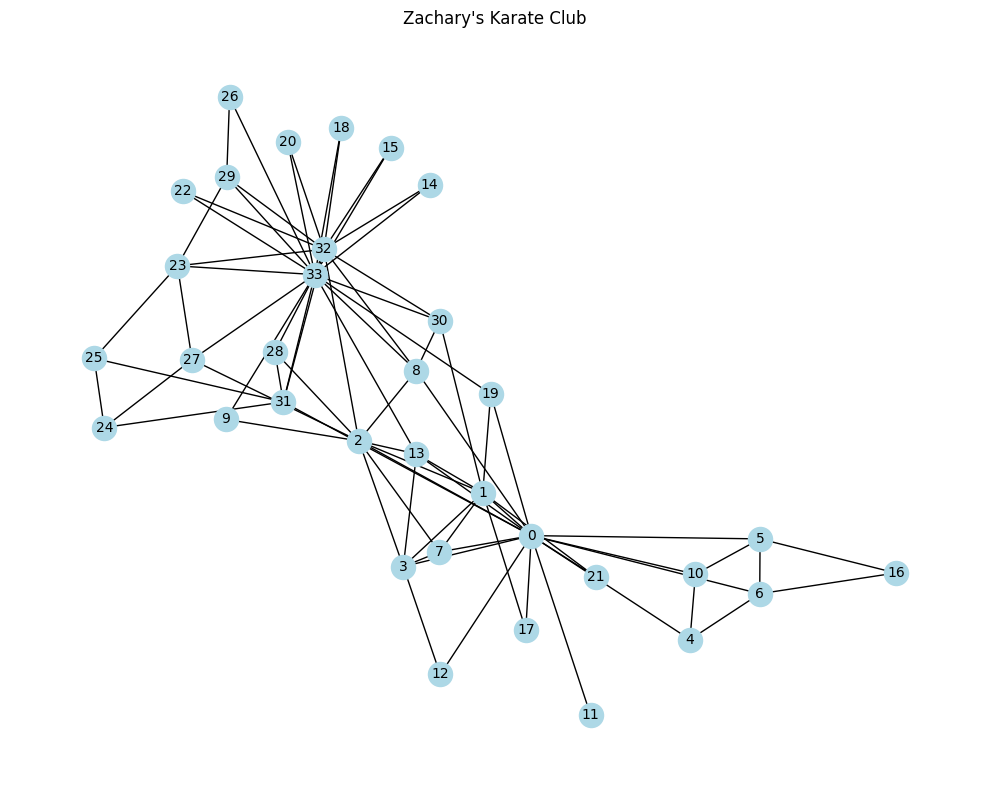

In [3]:
# Build NetworkX graph for visualization
rows, cols, _ = A.to_coo()
G = nx.Graph()
G.add_edges_from(zip(rows, cols))
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8))
draw_graph(G, pos=pos, ax=ax, title="Zachary's Karate Club", 
           directed=False, node_size=300, font_size=10, show=False)
plt.tight_layout()
plt.show()

## Triangle Counting: A² ⊙ A

In [4]:
# A² counts 2-hop paths between nodes
A2 = (A @ A).new()
print(f"A² has {A2.nvals} non-zero entries (pairs connected by 2-hop paths)")

A² has 698 non-zero entries (pairs connected by 2-hop paths)


In [5]:
# A² ⊙ A: where 2-hop paths AND direct edges exist = triangles
# Each triangle is counted 6 times (once per directed edge, both directions)
triangle_matrix = A2.ewise_mult(A, binary.times).new()
print(f"A² ⊙ A has {triangle_matrix.nvals} non-zero entries")

A² ⊙ A has 134 non-zero entries


In [6]:
# Total triangles = sum(A² ⊙ A) / 6
total = triangle_matrix.reduce_scalar(binary.plus).get()
num_triangles = total // 6
print(f"Total triangles: {num_triangles}")

Total triangles: 45


## More efficient Sandia Method

The above triangle counting scheme works, but is not maximally efficient.  First, it considers the entire symmetric graph, which involves counting both forward and backward edges, second it does an `ewise_mult` after the matrix multiply, requiring two operations instead of one.  The "sandia" method considers only the lower triangluar half of the matrix, counting half as many edges, and combines the ewise_mult operation into the matrix multiplication by using A as its own mask:

In [7]:
L = A.select('tril').new()
L(L.S) << L.mxm(L)
total = L.reduce_scalar(binary.plus).get()
print(f"Total triangles: {num_triangles}")

Total triangles: 45


## Per-Node Triangle Count

In [8]:
# Sum each row: triangles involving each node
# Each triangle counts twice per node (once for each neighbor in the triangle)
node_triangles = triangle_matrix.reduce_rowwise(binary.plus).new()
print(f"Nodes with triangles: {node_triangles.nvals} of {A.nrows}")

Nodes with triangles: 32 of 34


In [9]:
# Divide by 2 for actual count per node
node_triangles_actual = node_triangles.apply(binary.truediv, right=2).new()

# Show nodes with most triangles
indices, values = node_triangles_actual.to_coo()
tri_list = sorted(zip(indices, values), key=lambda x: -x[1])
print("Top 10 nodes by triangle count:")
for node, count in tri_list[:10]:
    print(f"  Node {int(node)}: {int(count)} triangles")

Top 10 nodes by triangle count:
  Node 0: 18 triangles
  Node 33: 15 triangles
  Node 32: 13 triangles
  Node 1: 12 triangles
  Node 2: 11 triangles
  Node 3: 10 triangles
  Node 7: 6 triangles
  Node 13: 6 triangles
  Node 8: 5 triangles
  Node 23: 4 triangles


## Visualizing Triangle Counts

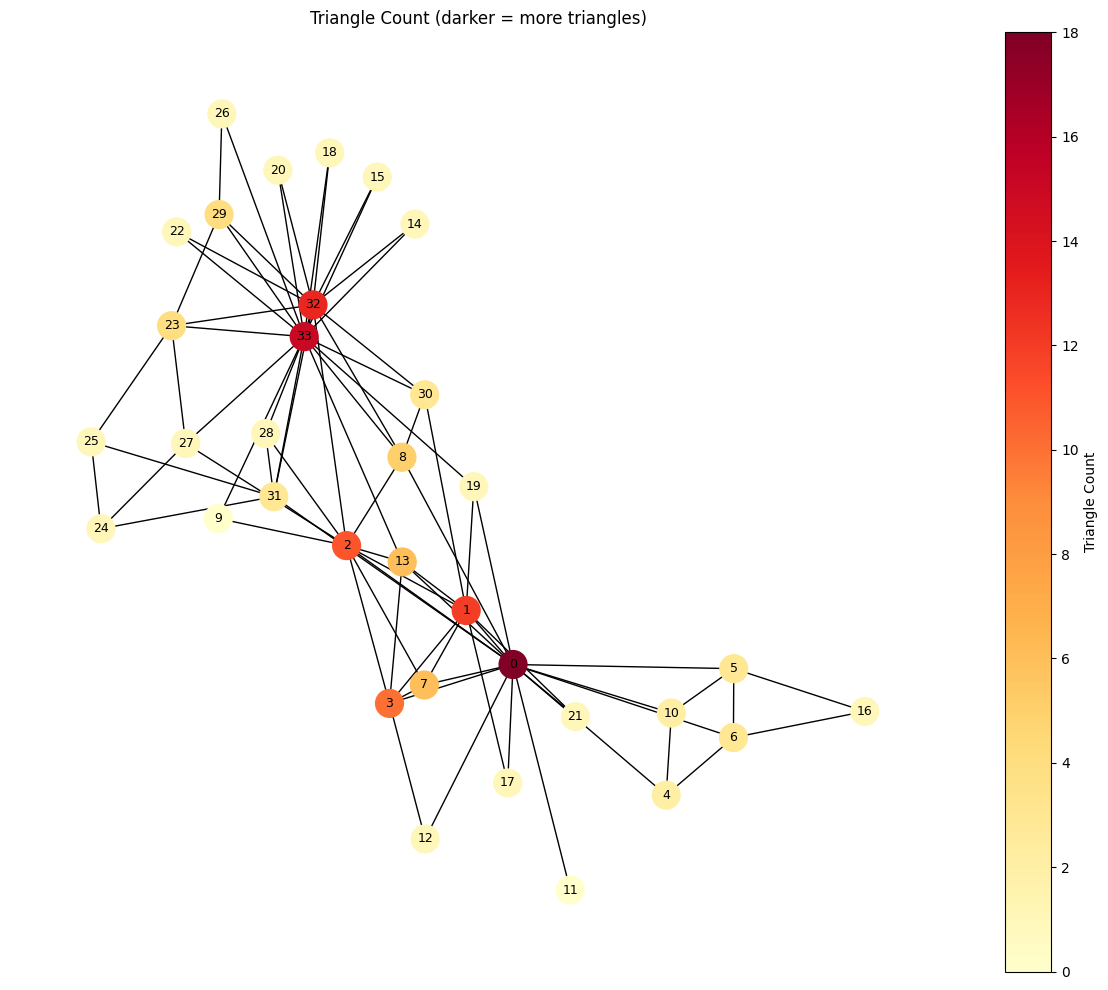

In [10]:
# Visualize triangle counts - nodes in more triangles are darker
fig, ax = plt.subplots(figsize=(12, 10))

# Color nodes by triangle count
indices, values = node_triangles_actual.to_coo()
tri_counts = {int(i): int(v) for i, v in zip(indices, values)}
# Use G.nodes() order to match how nx.draw applies colors
colors = [tri_counts.get(node, 0) for node in G.nodes()]

draw_graph(G, pos=pos, ax=ax, title="Triangle Count (darker = more triangles)",
           node_color=colors, cmap=plt.cm.YlOrRd, node_size=400, 
           font_size=9, directed=False, show=False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, 
                           norm=plt.Normalize(vmin=min(colors), vmax=max(colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Triangle Count')
plt.tight_layout()
plt.show()

## Triangle Centrality

Per-node triangle counts show how many triangles each node participates in, but **triangle centrality** measures vertex importance differently. A vertex is central if it concentrates triangles - either by being in many itself, or by connecting to neighbors who are in many.

Key insight from Burkhardt's algorithm: non-triangle neighbors' triangles count MORE than triangle neighbors' triangles. This is because non-triangle neighbors represent connections to OTHER clusters.

In [11]:
def triangle_centrality(A):
    """Triangle Centrality - identifies important vertices based on triangle concentration.
    
    From Burkhardt's paper: https://arxiv.org/abs/2105.00110
    
    TC = (3 * (A @ y) - 2 * (T1 @ y) + y) / k
    
    Where:
    - y = per-node triangle counts (row sums of triangle matrix)
    - k = sum of all triangle counts (normalization)
    - T1 = binary mask where triangles exist
    - A @ y = sum of ALL neighbors' triangle counts
    - T1 @ y = sum of TRIANGLE neighbors' triangle counts
    
    The 3 vs 2 weighting means non-triangle neighbors count more than triangle neighbors.
    """
    # y = per-node triangle counts
    T = A.dup(clear=True)
    T(A.S) << A.mxm(A.T)
    y = T.reduce_rowwise(binary.plus).new()
    
    # k = normalization factor (sum of all triangle counts)
    k = y.reduce(binary.plus).new().value
    
    # T1 = where triangles exist (binary mask)
    T1 = T.dup(bool)
      
    tc = (3 * (A @ y) + -2 * (T1 @ y) + y) / k
    
    return tc.new()

tc = triangle_centrality(A)
print(f"Triangle centrality computed for {tc.nvals} nodes")

Triangle centrality computed for 34 nodes


In [12]:
# Display top nodes by triangle centrality
indices, values = tc.to_coo()
tc_list = sorted(zip(indices, values), key=lambda x: -x[1])
print("Top 10 nodes by triangle centrality:")
for node, score in tc_list[:10]:
    print(f"  Node {int(node)}: {score:.4f}")

Top 10 nodes by triangle centrality:
  Node 13: 0.7556
  Node 0: 0.6741
  Node 31: 0.6519
  Node 2: 0.6444
  Node 9: 0.5778
  Node 19: 0.5630
  Node 33: 0.5630
  Node 1: 0.5556
  Node 30: 0.5333
  Node 8: 0.4815


In [13]:
# Compare triangle count vs triangle centrality rankings
# Get triangle count ranking
tri_indices, tri_values = node_triangles_actual.to_coo()
tri_rank = {int(node): rank for rank, (node, _) in enumerate(sorted(zip(tri_indices, tri_values), key=lambda x: -x[1]))}

# Get triangle centrality ranking  
tc_indices, tc_values = tc.to_coo()
tc_rank = {int(node): rank for rank, (node, _) in enumerate(sorted(zip(tc_indices, tc_values), key=lambda x: -x[1]))}

# Build comparison data
tri_dict = {int(i): v for i, v in zip(tri_indices, tri_values)}
tc_dict = {int(i): v for i, v in zip(tc_indices, tc_values)}

print("Comparing rankings (sorted by triangle count):")
print(f"{'Node':<6} {'Tri Count':<12} {'TC Score':<12} {'Count Rank':<12} {'TC Rank':<12} {'Rank Diff':<10}")
print("-" * 64)

for node, count in sorted(tri_dict.items(), key=lambda x: -x[1])[:15]:
    tc_score = tc_dict.get(node, 0)
    t_rank = tri_rank.get(node, -1)
    c_rank = tc_rank.get(node, -1)
    diff = t_rank - c_rank
    diff_str = f"+{diff}" if diff > 0 else str(diff)
    print(f"{node:<6} {count:<12.0f} {tc_score:<12.4f} {t_rank:<12} {c_rank:<12} {diff_str:<10}")

Comparing rankings (sorted by triangle count):
Node   Tri Count    TC Score     Count Rank   TC Rank      Rank Diff 
----------------------------------------------------------------
0      18           0.6741       0            1            -1        
33     15           0.5630       1            6            -5        
32     13           0.4667       2            11           -9        
1      12           0.5556       3            7            -4        
2      11           0.6444       4            3            +1        
3      10           0.4741       5            10           -5        
7      6            0.4222       6            12           -6        
13     6            0.7556       7            0            +7        
8      5            0.4815       8            9            -1        
23     4            0.2963       9            16           -7        
29     4            0.2741       10           17           -7        
5      3            0.2000       11           26

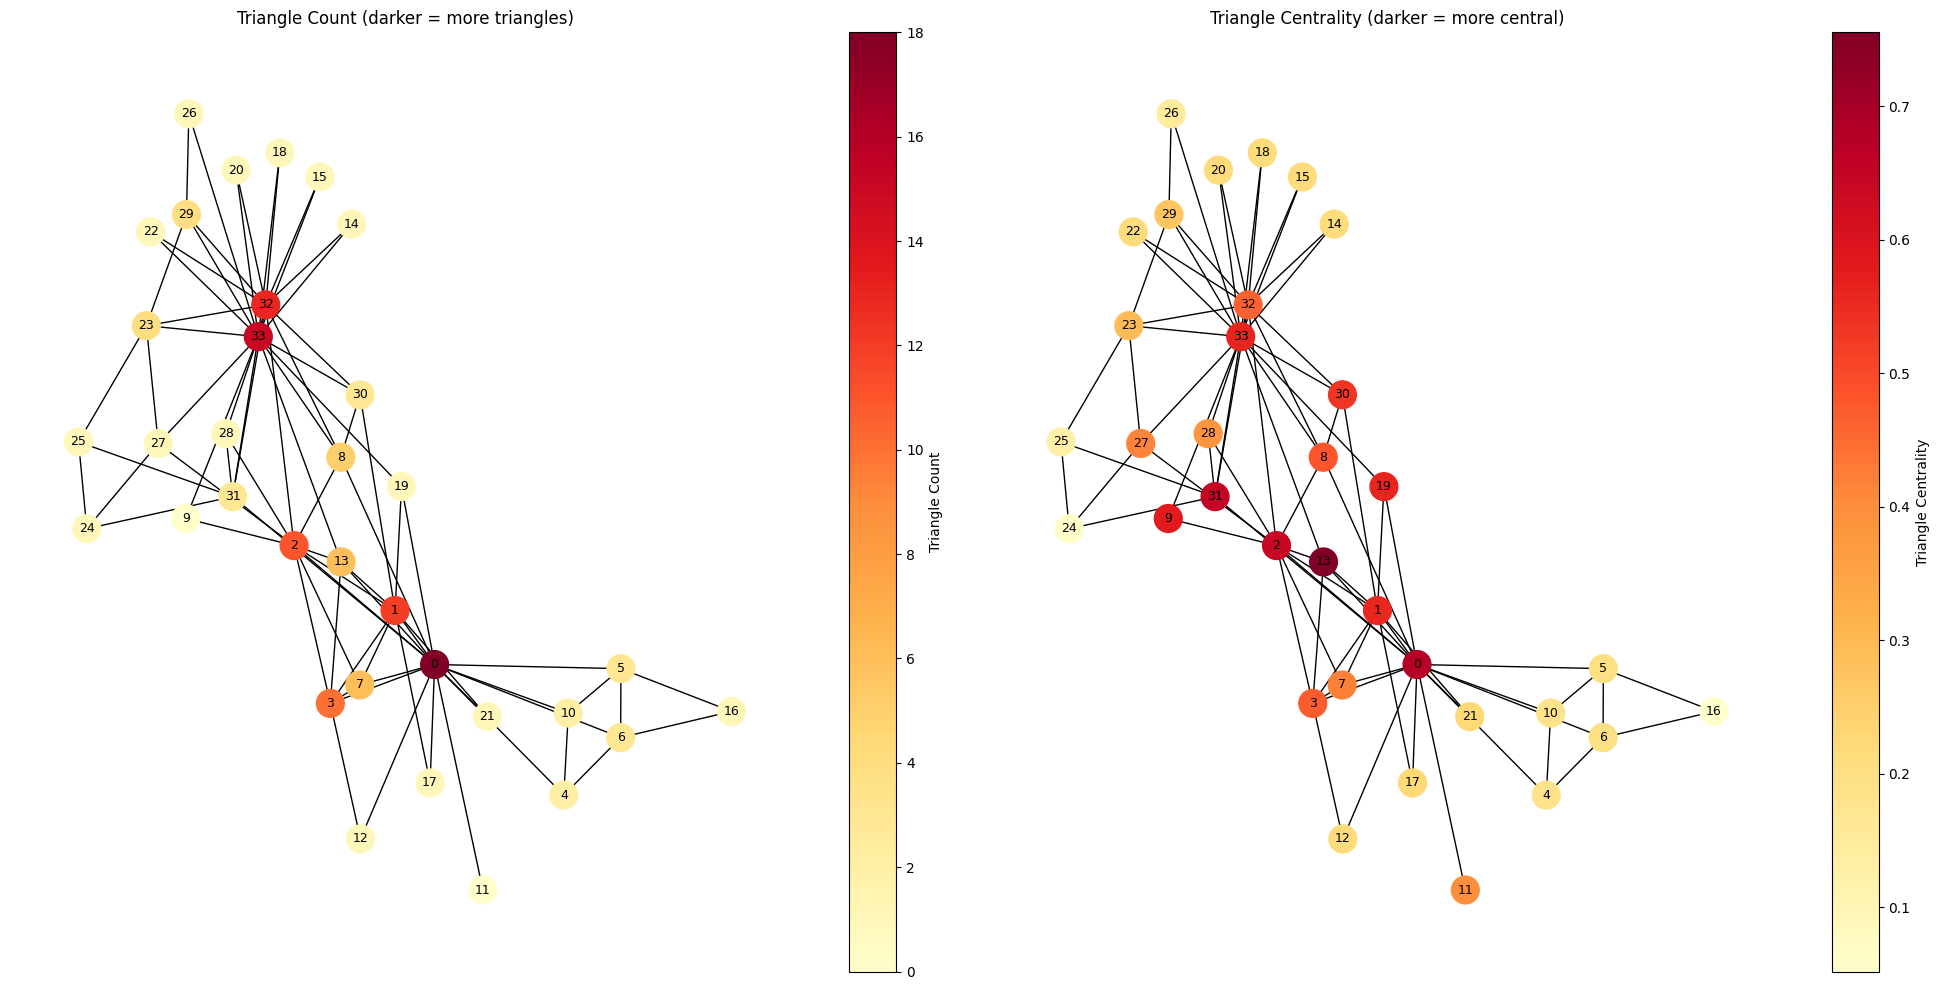

In [14]:
# Visualize triangle counts vs triangle centrality side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Triangle counts (same as before)
tri_colors = [tri_dict.get(node, 0) for node in G.nodes()]
draw_graph(G, pos=pos, ax=axes[0], title="Triangle Count (darker = more triangles)",
           node_color=tri_colors, cmap=plt.cm.YlOrRd, node_size=400,
           font_size=9, directed=False, show=False)
sm1 = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                            norm=plt.Normalize(vmin=min(tri_colors), vmax=max(tri_colors)))
sm1.set_array([])
plt.colorbar(sm1, ax=axes[0], label='Triangle Count')

# Right: Triangle centrality
tc_colors = [tc_dict.get(node, 0) for node in G.nodes()]
draw_graph(G, pos=pos, ax=axes[1], title="Triangle Centrality (darker = more central)",
           node_color=tc_colors, cmap=plt.cm.YlOrRd, node_size=400,
           font_size=9, directed=False, show=False)
sm2 = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                            norm=plt.Normalize(vmin=min(tc_colors), vmax=max(tc_colors)))
sm2.set_array([])
plt.colorbar(sm2, ax=axes[1], label='Triangle Centrality')

plt.tight_layout()
plt.show()

In [15]:
# Export triangle centrality values for use in Manim scenes
print("\n# KARATE_TRIANGLE_CENTRALITY for scene_utils/graph_utils.py")
print("KARATE_TRIANGLE_CENTRALITY = {")
for node in sorted(tc_dict.keys()):
    print(f"    {node}: {tc_dict[node]:.6f},")
print("}")


# KARATE_TRIANGLE_CENTRALITY for scene_utils/graph_utils.py
KARATE_TRIANGLE_CENTRALITY = {
    0: 0.674074,
    1: 0.555556,
    2: 0.644444,
    3: 0.474074,
    4: 0.185185,
    5: 0.200000,
    6: 0.200000,
    7: 0.422222,
    8: 0.481481,
    9: 0.577778,
    10: 0.185185,
    11: 0.400000,
    12: 0.214815,
    13: 0.755556,
    14: 0.214815,
    15: 0.214815,
    16: 0.051852,
    17: 0.229630,
    18: 0.214815,
    19: 0.562963,
    20: 0.214815,
    21: 0.229630,
    22: 0.214815,
    23: 0.296296,
    24: 0.059259,
    25: 0.125926,
    26: 0.148148,
    27: 0.414815,
    28: 0.385185,
    29: 0.274074,
    30: 0.533333,
    31: 0.651852,
    32: 0.466667,
    33: 0.562963,
}
